# Loading data (electric power consumption  - https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption)

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('powerconsumption.csv', parse_dates=['Datetime'])
df.set_index('Datetime', inplace=True)
# hourly aggregation in order to catch weekly trends
df_hourly = df.resample('h').mean()

print(df_hourly.columns)
print(np.sum(df_hourly.isnull()))
df_hourly.describe()

Index(['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
       'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2',
       'PowerConsumption_Zone3'],
      dtype='object')
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.807624,15.475739,2.340551,260.820277,119.691920,7068.919876,5165.178202,6591.013989
min,3.602167,12.710000,0.054667,0.019000,0.040000,14329.113923,8685.947047,6190.636254
25%,14.403750,58.324583,0.078167,0.064000,0.124167,26292.951730,17016.901716,13148.470246
50%,18.759167,69.815833,0.085500,9.947417,8.241250,32342.303347,20787.229493,16427.659642
75%,22.866667,81.350000,4.915333,326.487500,105.883333,37318.002218,24677.609019,21598.447824
max,39.695000,94.750000,5.933667,953.350000,861.000000,51844.261932,36254.699050,47223.765690


# Feature engineering

In [185]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek

features = ['Temperature', 'Humidity', 'WindSpeed', 'hour', 'dayofweek', 'PowerConsumption_Zone1']

data_filtered = df_hourly[features].copy()

target_idx = features.index('PowerConsumption_Zone1')

data_filtered.describe()

,Temperature,Humidity,WindSpeed,hour,dayofweek,PowerConsumption_Zone1
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,18.810024,68.259518,1.959489,11.500000,3.000000,32344.970564
std,5.807624,15.475739,2.340551,6.922583,2.000114,7068.919876
min,3.602167,12.710000,0.054667,0.000000,0.000000,14329.113923
25%,14.403750,58.324583,0.078167,5.750000,1.000000,26292.951730
50%,18.759167,69.815833,0.085500,11.500000,3.000000,32342.303347
75%,22.866667,81.350000,4.915333,17.250000,5.000000,37318.002218
max,39.695000,94.750000,5.933667,23.000000,6.000000,51844.261932


# 4.1

## LSTM

In [186]:
from torch.utils.data import Dataset, DataLoader

class MultivariateSeqDataset(Dataset):
    def __init__(self, data, seq_len, horizon, target_idx=0, seq2seq=False):
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.horizon = horizon
        self.tidx = target_idx
        self.seq2seq = seq2seq
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
        
    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        if self.seq2seq:
            # Seq2Seq - predict whole sequence of length horizon
            y = self.data[i + self.seq_len : i + self.seq_len + self.horizon, self.tidx]
        else:
            # Seq2One - predict only one datapoint
            y = self.data[i + self.seq_len + self.horizon - 1, self.tidx]
        return x, y

class LSTMSeq2One(nn.Module):
    def __init__(self, input_size=4, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, dropout=dropout if layers>1 else 0, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1]).squeeze(-1)


class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size=4, hidden=64, layers=2, horizon=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, dropout=dropout if layers>1 else 0, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )
        
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

In [187]:
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Active device: {device}")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def train_lstm(model, train_loader, test_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
        val_loss = val_loss / len(test_loader.dataset)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
    return model, train_losses, val_losses

Active device: mps


## Seq2seq

Training: LSTM_seq=12
Epoch 5/15 | Train Loss: 0.2187 | Val Loss: 0.6989
Epoch 10/15 | Train Loss: 0.2379 | Val Loss: 0.6639
Epoch 15/15 | Train Loss: 0.1683 | Val Loss: 0.4103
Training: LSTM_seq=24
Epoch 5/15 | Train Loss: 0.2173 | Val Loss: 0.6363
Epoch 10/15 | Train Loss: 0.2183 | Val Loss: 0.5578
Epoch 15/15 | Train Loss: 0.1593 | Val Loss: 0.4147
Training: LSTM_seq=36
Epoch 5/15 | Train Loss: 0.2045 | Val Loss: 0.5812
Epoch 10/15 | Train Loss: 0.2153 | Val Loss: 0.5792
Epoch 15/15 | Train Loss: 0.1365 | Val Loss: 0.3470
Training: LSTM_seq=48
Epoch 5/15 | Train Loss: 0.2124 | Val Loss: 0.6248
Epoch 10/15 | Train Loss: 0.2079 | Val Loss: 0.5219
Epoch 15/15 | Train Loss: 0.1517 | Val Loss: 0.3380
Training: LSTM_seq=96
Epoch 5/15 | Train Loss: 0.2138 | Val Loss: 0.6631
Epoch 10/15 | Train Loss: 0.2226 | Val Loss: 0.6157
Epoch 15/15 | Train Loss: 0.1831 | Val Loss: 0.4706
Training: LSTM_seq=168
Epoch 5/15 | Train Loss: 0.2170 | Val Loss: 0.6702
Epoch 10/15 | Train Loss: 0.2208 | Val Lo

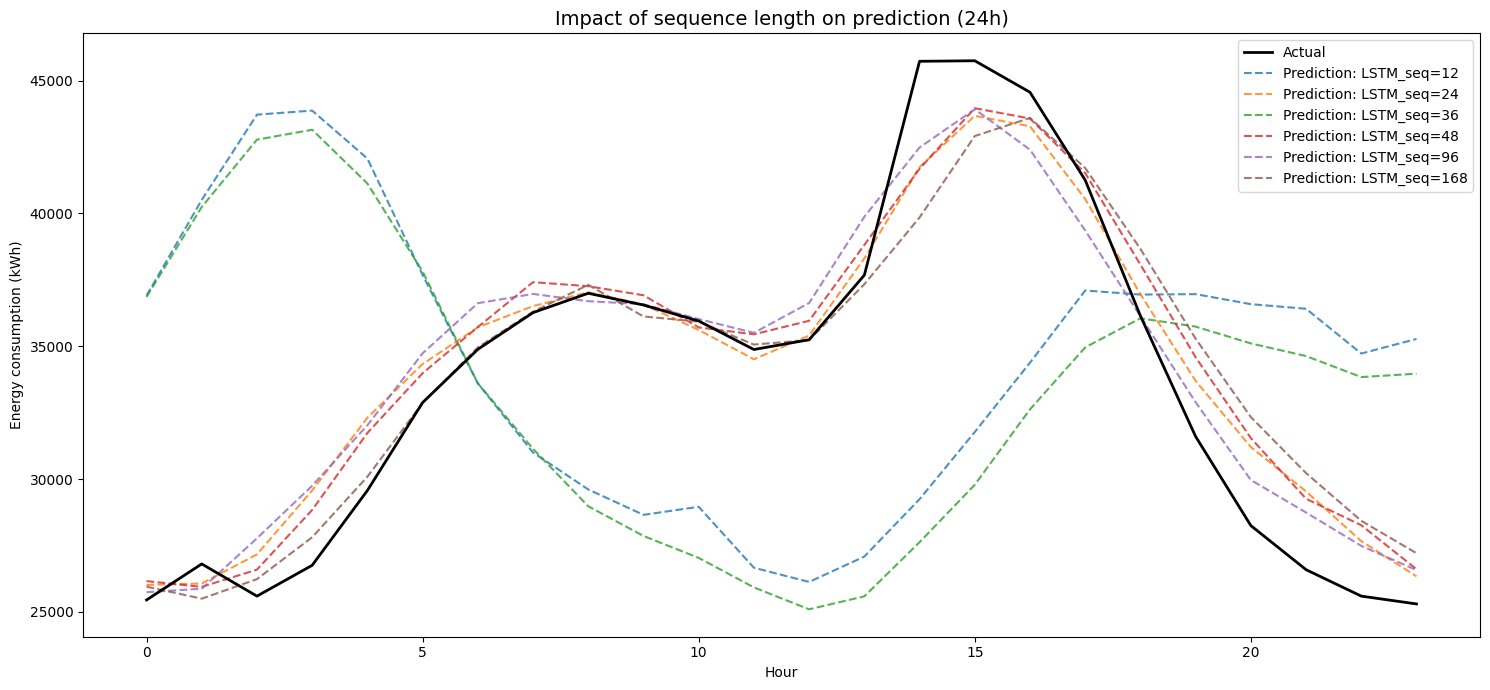

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

# test, train, scale
n_train = int(0.8 * len(data_filtered))
train_data_orig = data_filtered.iloc[:n_train]
test_data_orig = data_filtered.iloc[n_train:]

scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data_orig)
test_data_scaled = scaler.transform(test_data_orig)

INPUT_SIZE = len(features)
HORIZON = 24
BATCH_SIZE = 64


def plot_comparison(test_df, predictions_dict, target_col, horizon):
    plt.figure(figsize=(15, 7))
    
    actual = test_df[target_col].values[:horizon]
    plt.plot(actual, label='Actual', color='black', lw=2, zorder=10)
    
    for name, preds in predictions_dict.items():
        plt.plot(preds, label=f'Prediction: {name}', linestyle='--', alpha=0.8)
        
    plt.title(f'Impact of sequence length on prediction ({horizon}h)', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('Energy consumption (kWh)')
    plt.legend()
    plt.tight_layout()
    plt.show()

all_preds_to_plot = {}
seq_lengths = [12, 24, 36, 48, 96, 168]

for s_len in seq_lengths:
    exp_name = f'LSTM_seq={s_len}'
    print(f"Training: {exp_name}")
    
    train_ds = MultivariateSeqDataset(train_data_scaled, s_len, HORIZON, target_idx, seq2seq=True)
    test_ds = MultivariateSeqDataset(test_data_scaled, s_len, HORIZON, target_idx, seq2seq=True)
    
    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = LSTMSeq2Seq(input_size=len(features), hidden=64, horizon=HORIZON).to(device)
    trained_model, _, _ = train_lstm(model, tr_loader, te_loader, epochs=15)
    
    model.eval()
    with torch.no_grad():
        x_sample, _ = test_ds[0]
        x_sample = x_sample.unsqueeze(0).to(device)
        pred_scaled = model(x_sample).cpu().numpy().flatten()
        
        dummy = np.zeros((HORIZON, len(features)))
        dummy[:, target_idx] = pred_scaled
        pred_final = scaler.inverse_transform(dummy)[:, target_idx]
        
        all_preds_to_plot[exp_name] = pred_final

test_df_orig = data_filtered.iloc[n_train:]
plot_comparison(test_df_orig, all_preds_to_plot, 'PowerConsumption_Zone1', HORIZON)

## Seq2One


Training for seq_len=12, hidden_units=16
Epoch 5/15 | Train Loss: 0.1013 | Val Loss: 0.1785
Epoch 10/15 | Train Loss: 0.0867 | Val Loss: 0.1846
Epoch 15/15 | Train Loss: 0.0795 | Val Loss: 0.1848

Training for seq_len=12, hidden_units=32
Epoch 5/15 | Train Loss: 0.0880 | Val Loss: 0.1860
Epoch 10/15 | Train Loss: 0.0707 | Val Loss: 0.1660
Epoch 15/15 | Train Loss: 0.0620 | Val Loss: 0.1404

Training for seq_len=12, hidden_units=48
Epoch 5/15 | Train Loss: 0.0887 | Val Loss: 0.1922
Epoch 10/15 | Train Loss: 0.0698 | Val Loss: 0.1527
Epoch 15/15 | Train Loss: 0.0592 | Val Loss: 0.1439

Training for seq_len=12, hidden_units=64
Epoch 5/15 | Train Loss: 0.0827 | Val Loss: 0.1293
Epoch 10/15 | Train Loss: 0.0651 | Val Loss: 0.1332
Epoch 15/15 | Train Loss: 0.0550 | Val Loss: 0.1145

Training for seq_len=24, hidden_units=16
Epoch 5/15 | Train Loss: 0.1062 | Val Loss: 0.1897
Epoch 10/15 | Train Loss: 0.0898 | Val Loss: 0.1801
Epoch 15/15 | Train Loss: 0.0812 | Val Loss: 0.1669

Training for s

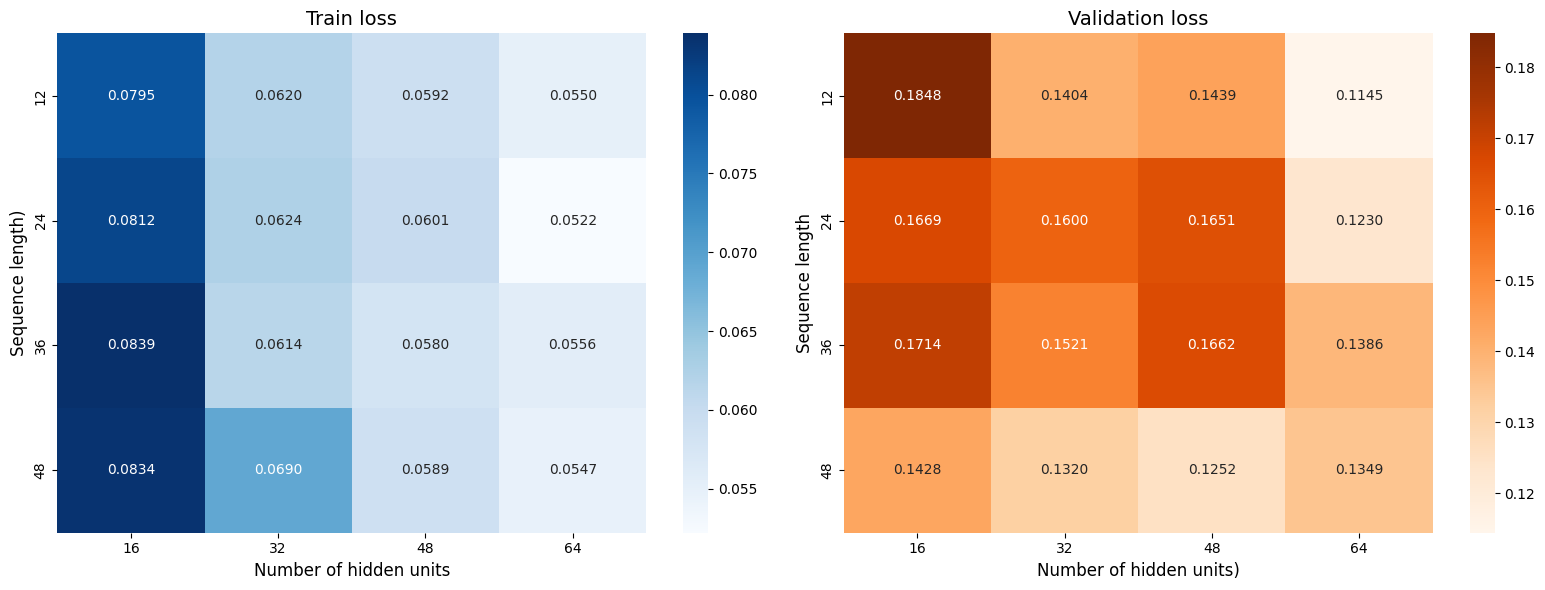

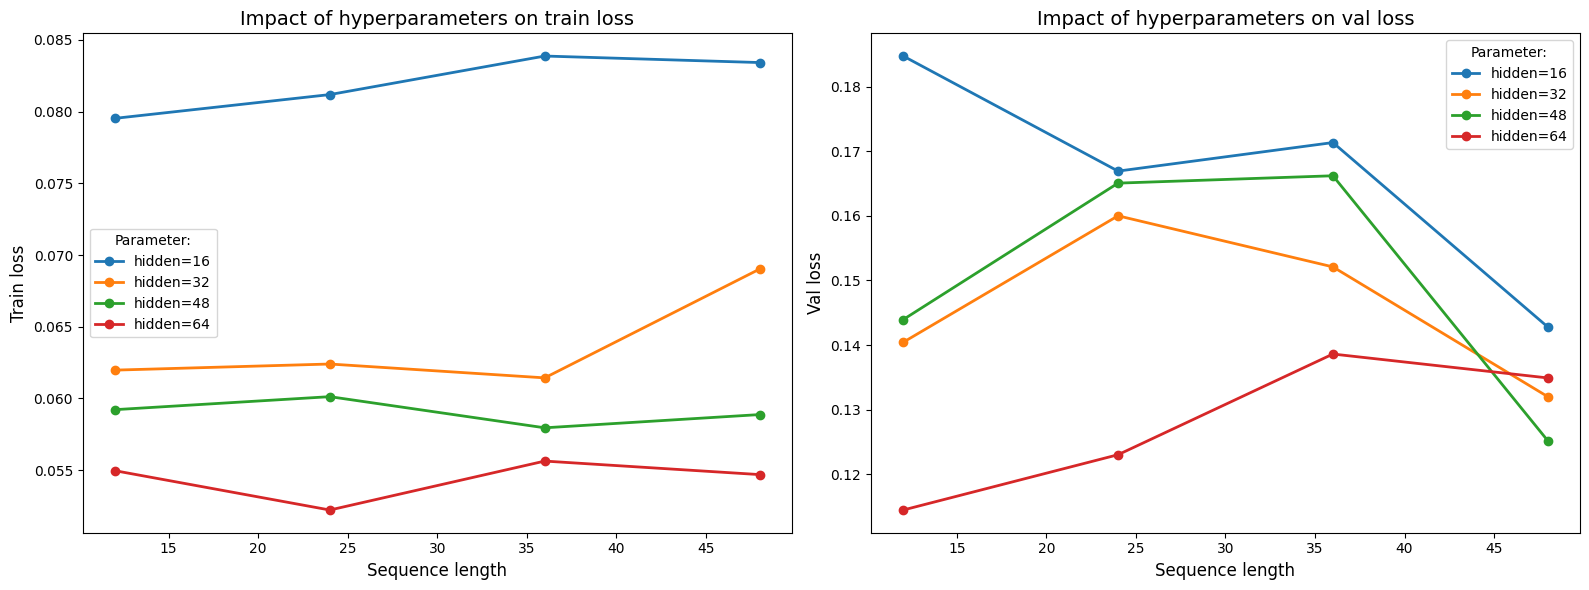

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

seq_lengths = [12, 24, 36, 48]
hidden_sizes = [16, 32, 48, 64]

final_train_losses = np.zeros((len(seq_lengths), len(hidden_sizes)))
final_val_losses = np.zeros((len(seq_lengths), len(hidden_sizes)))

for i, seq in enumerate(seq_lengths):
    for j, hid in enumerate(hidden_sizes):
        print(f"\nTraining for seq_len={seq}, hidden_units={hid}")
        
        train_ds = MultivariateSeqDataset(train_data_scaled, seq, HORIZON, target_idx, seq2seq=False)
        test_ds = MultivariateSeqDataset(test_data_scaled, seq, HORIZON, target_idx, seq2seq=False)
        
        tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
        te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        model = LSTMSeq2One(input_size=len(features), hidden=hid).to(device)
        
        trained_model, t_loss, v_loss = train_lstm(model, tr_loader, te_loader, epochs=15)
        
        final_train_losses[i, j] = t_loss[-1]
        final_val_losses[i, j] = v_loss[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(final_train_losses, annot=True, fmt=".4f", 
            xticklabels=hidden_sizes, yticklabels=seq_lengths, cmap="Blues", ax=axes[0])
axes[0].set_title("Train loss", fontsize=14)
axes[0].set_xlabel("Number of hidden units", fontsize=12)
axes[0].set_ylabel("Sequence length)", fontsize=12)

sns.heatmap(final_val_losses, annot=True, fmt=".4f", 
            xticklabels=hidden_sizes, yticklabels=seq_lengths, cmap="Oranges", ax=axes[1])
axes[1].set_title("Validation loss", fontsize=14)
axes[1].set_xlabel("Number of hidden units)", fontsize=12)
axes[1].set_ylabel("Sequence length", fontsize=12)

plt.tight_layout()
plt.show()

# --- WIZUALIZACJA 2: WYKRESY LINIOWE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j, hid in enumerate(hidden_sizes):
    axes[0].plot(seq_lengths, final_train_losses[:, j], marker='o', lw=2, label=f'hidden={hid}')
    axes[1].plot(seq_lengths, final_val_losses[:, j], marker='o', lw=2, label=f'hidden={hid}')

axes[0].set_title("Impact of hyperparameters on train loss", fontsize=14)
axes[0].set_xlabel("Sequence length", fontsize=12)
axes[0].set_ylabel("Train loss", fontsize=12)
axes[0].legend(title="Parameter:")

axes[1].set_title("Impact of hyperparameters on val loss", fontsize=14)
axes[1].set_xlabel("Sequence length", fontsize=12)
axes[1].set_ylabel("Val loss", fontsize=12)
axes[1].legend(title="Parameter:")

plt.tight_layout()
plt.show()

## LSTM vs Prophet vs ARIMA

p-value: 0.0000


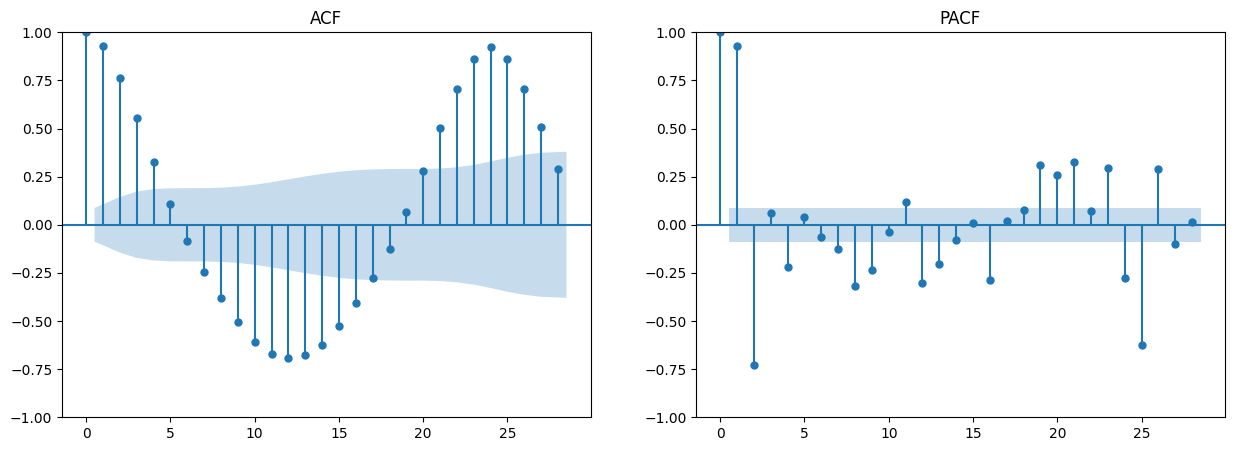

01:55:41 - cmdstanpy - INFO - Chain [1] start processing
01:55:43 - cmdstanpy - INFO - Chain [1] done processing


Epoch 5/15 | Train Loss: 0.0998 | Val Loss: 0.1160
Epoch 10/15 | Train Loss: 0.0840 | Val Loss: 0.1094
Epoch 15/15 | Train Loss: 0.0737 | Val Loss: 0.0964
ARIMA          : 5175.76
Prophet        : 1640.45
LSTM           : 4775.31


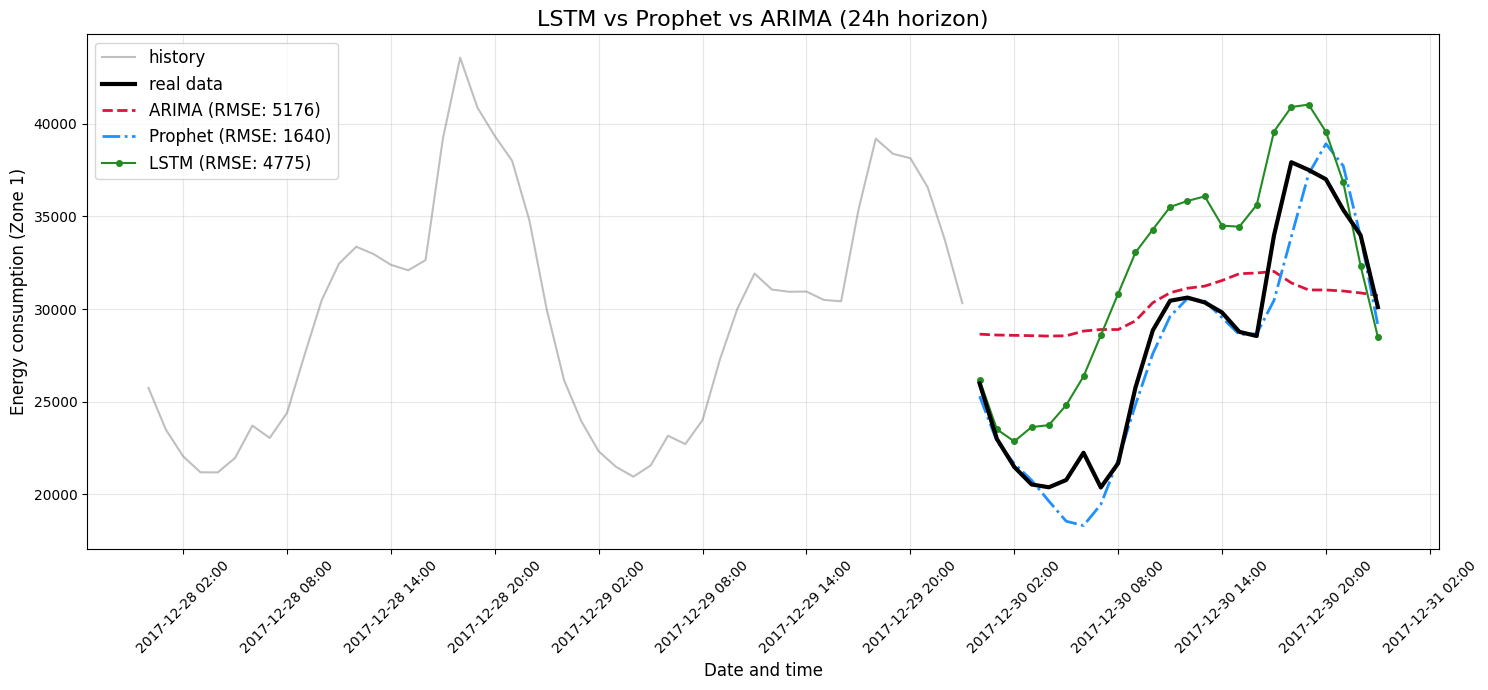

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# 1 DATA
HORIZON = 24
target_col = 'PowerConsumption_Zone1'
exog_cols = ['Temperature', 'Humidity', 'WindSpeed', 'hour', 'dayofweek']

train_orig = data_filtered.iloc[:-HORIZON].copy()
test_orig = data_filtered.iloc[-HORIZON:].copy()

results_rmse = {}
model_predictions = {}

# 2 ARIMA

recent_train_orig = train_orig.iloc[-504:]
target_series = recent_train_orig[target_col]

adf_result = adfuller(target_series)
print(f"p-value: {adf_result[1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(target_series, ax=ax1, title="ACF")
plot_pacf(target_series, ax=ax2, title="PACF")
plt.show()

arima_exog_cols = ['Temperature', 'Humidity', 'WindSpeed']

arima_model = ARIMA(endog=target_series,
                    exog=recent_train_orig[arima_exog_cols],
                    order=(1, 0, 1),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

arima_fit = arima_model.fit()

# forecast
forecast_obj = arima_fit.get_forecast(steps=HORIZON, exog=test_orig[arima_exog_cols])
model_predictions['ARIMA'] = forecast_obj.predicted_mean.values
results_rmse['ARIMA'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['ARIMA']))

# 3 Prophet

prophet_df = train_orig.reset_index().rename(columns={'Datetime': 'ds', target_col: 'y'})

model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
for col in exog_cols:
    model_prophet.add_regressor(col)

model_prophet.fit(prophet_df)

future_df = test_orig.reset_index().rename(columns={'Datetime': 'ds'})
prophet_preds_full = model_prophet.predict(future_df)
model_predictions['Prophet'] = prophet_preds_full['yhat'].values
results_rmse['Prophet'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['Prophet']))


# 4 LSTM
SEQ_LEN = 24
HIDDEN_UNITS = 32

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_orig)

split_idx = int(0.9 * len(train_scaled))
lstm_train_data = train_scaled[:split_idx]
lstm_val_data = train_scaled[split_idx:]

train_ds = MultivariateSeqDataset(lstm_train_data, SEQ_LEN, HORIZON, target_idx, seq2seq=True)
val_ds = MultivariateSeqDataset(lstm_val_data, SEQ_LEN, HORIZON, target_idx, seq2seq=True)

tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model_lstm = LSTMSeq2Seq(input_size=len(features), hidden=HIDDEN_UNITS, horizon=HORIZON).to(device)

trained_model, _, _ = train_lstm(model_lstm, tr_loader, val_loader, epochs=15)

model_lstm.eval()
with torch.no_grad():
    x_input = torch.FloatTensor(train_scaled[-SEQ_LEN:]).unsqueeze(0).to(device)
    pred_scaled = model_lstm(x_input).cpu().numpy().flatten()
    
    dummy = np.zeros((HORIZON, len(features)))
    dummy[:, target_idx] = pred_scaled
    pred_final = scaler.inverse_transform(dummy)[:, target_idx]
    
model_predictions['LSTM'] = pred_final
results_rmse['LSTM'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['LSTM']))


# Visualization
for name, error in results_rmse.items():
    print(f"{name: <15}: {error:.2f}")

plt.figure(figsize=(15, 7))
plt.plot(train_orig.index[-48:], train_orig[target_col].iloc[-48:], color='grey', label='history', alpha=0.5)

plt.plot(test_orig.index, test_orig[target_col], label='real data', color='black', lw=3, zorder=10)

plt.plot(test_orig.index, model_predictions['ARIMA'], label=f"ARIMA (RMSE: {results_rmse['ARIMA']:.0f})", color='crimson', ls='--', lw=2)
plt.plot(test_orig.index, model_predictions['Prophet'], label=f"Prophet (RMSE: {results_rmse['Prophet']:.0f})", color='dodgerblue', ls='-.', lw=2)
plt.plot(test_orig.index, model_predictions['LSTM'], label=f"LSTM (RMSE: {results_rmse['LSTM']:.0f})", color='forestgreen', ls='-', marker='o', markersize=4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)

plt.title('LSTM vs Prophet vs ARIMA (24h horizon)', fontsize=16)
plt.xlabel('Date and time', fontsize=12)
plt.ylabel('Energy consumption (Zone 1)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2

In [191]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


SEQ_LEN_ATTN = 48
HIDDEN_UNITS_ATTN = 64

train_ds_attn = MultivariateSeqDataset(train_data_scaled, SEQ_LEN_ATTN, HORIZON, target_idx, seq2seq=True)
test_ds_attn = MultivariateSeqDataset(test_data_scaled, SEQ_LEN_ATTN, HORIZON, target_idx, seq2seq=True)
tr_loader_attn = DataLoader(train_ds_attn, batch_size=BATCH_SIZE, shuffle=True)
te_loader_attn = DataLoader(test_ds_attn, batch_size=BATCH_SIZE, shuffle=False)

class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size=len(features), hidden=64, layers=2, dropout=0.2, n_heads=4, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, 
                            dropout=dropout if layers>1 else 0, 
                            batch_first=True)
        
        # nn.MultiheadAttention: Q=K=V=lstm_output (self-attention)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden, 
            num_heads=n_heads, 
            dropout=dropout, 
            batch_first=True
        )
        
        self.norm = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), 
            nn.GELU(), 
            nn.Linear(32, horizon)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (Batch, T, hidden)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out) 
        
        out = self.norm(lstm_out + attn_out) # residual + LN
        pooled = self.dropout(out.mean(dim=1)) # global avg pool
        
        return self.head(pooled)

model_attn = LSTMAttentionModel(input_size=len(features), hidden=HIDDEN_UNITS_ATTN, horizon=HORIZON).to(device)

print(f"LSTM+Attention: {sum(p.numel() for p in model_attn.parameters()):,}")

trained_attn, tr_loss_attn, val_loss_attn = train_lstm(model_attn, tr_loader_attn, te_loader_attn, epochs=15)

model_attn.eval()
with torch.no_grad():
    x_input = torch.FloatTensor(train_scaled[-SEQ_LEN_ATTN:]).unsqueeze(0).to(device)
    pred_scaled = model_attn(x_input).cpu().numpy().flatten()
    
    dummy = np.zeros((HORIZON, len(features)))
    dummy[:, target_idx] = pred_scaled
    pred_final_attn = scaler.inverse_transform(dummy)[:, target_idx]

rmse_attn = np.sqrt(mean_squared_error(test_orig[target_col], pred_final_attn))
print(f"RMSE for LSTM+Attention: {rmse_attn:.2f}")

LSTM+Attention: 71,352
Epoch 5/15 | Train Loss: 0.1436 | Val Loss: 0.1109
Epoch 10/15 | Train Loss: 0.1074 | Val Loss: 0.1145
Epoch 15/15 | Train Loss: 0.0929 | Val Loss: 0.1113
RMSE for LSTM+Attention: 6457.37


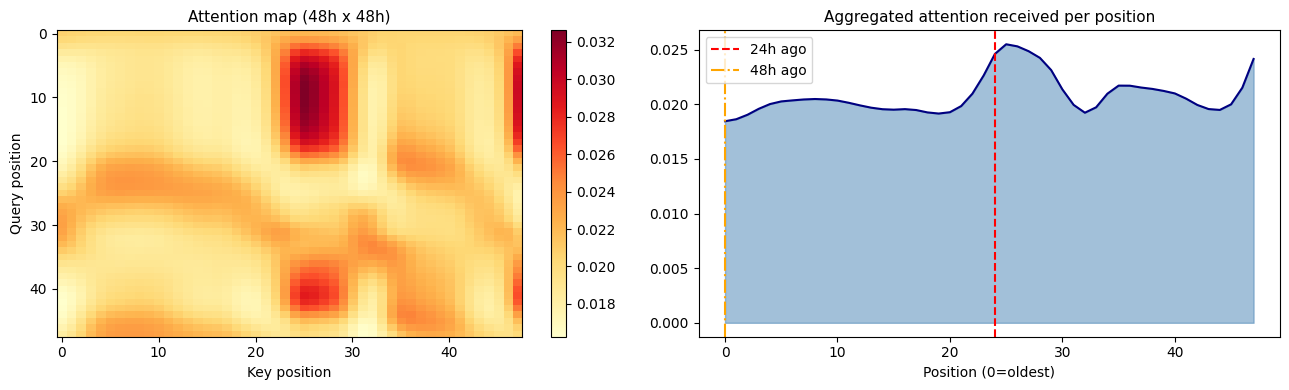

In [193]:
model_attn.eval()

sample_x, _ = train_ds_attn[0] 
sx = sample_x.unsqueeze(0).to(device)

with torch.no_grad():
    lo, _ = model_attn.lstm(sx)
    attn_out, w = model_attn.attn(lo, lo, lo) 
    
    avg_w = w[0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(avg_w, aspect='auto', cmap='YlOrRd')
axes[0].set_title(f'Attention map ({SEQ_LEN_ATTN}h x {SEQ_LEN_ATTN}h)', fontsize=11)
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
plt.colorbar(im, ax=axes[0])

# Aggregated attention received per position
received = avg_w.mean(axis=0)
axes[1].fill_between(range(SEQ_LEN_ATTN), received, alpha=0.5, color='steelblue')
axes[1].plot(received, color='navy')
axes[1].axvline(SEQ_LEN_ATTN-24, color='red', ls='--', label='24h ago')

if SEQ_LEN_ATTN >= 48:
    axes[1].axvline(SEQ_LEN_ATTN-48, color='orange', ls='-.', label='48h ago')

axes[1].set_title('Aggregated attention received per position', fontsize=11)
axes[1].set_xlabel('Position (0=oldest)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4.3

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

In [196]:
try:
    from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
    from pytorch_forecasting.data import GroupNormalizer
    from pytorch_forecasting.metrics import QuantileLoss
    import lightning.pytorch as pl
    from lightning.pytorch.loggers import CSVLogger
    TFT_AVAILABLE = True
except ImportError:
    TFT_AVAILABLE = False
    print("Please install: pip install pytorch-forecasting lightning")

if TFT_AVAILABLE:
    # Data preparation
    df = pd.read_csv('mock_kaggle.csv')
    df["data"] = pd.to_datetime(df["data"])
    df = df.sort_values("data")

    # Required features
    df["time_idx"] = np.arange(len(df))
    # STORE ID AND LOCATION
    store_ids = [str(i) for i in range(1, 2)]
    top_1_state = [
    "Texas"
    ]
    np.random.seed(69)
    store_locations = {store: np.random.choice(top_1_state) for store in store_ids}
    df["store"] = np.random.choice(list(store_locations.keys()), size=len(df))
    df["location"] = df["store"].map(store_locations)
    # Time-varying features (Promotions & Holidays)

    df["promotion"] = (df["preco"] < df["preco"].mean()).astype(str)
    df["holiday"]   = df["data"].dt.dayofweek.map({5: "1", 6: "1"}).fillna("0")
    df["day_of_week"] = df["data"].dt.dayofweek.astype(str)

!! The model requires at least MAX_ENC + MAX_PRED time steps for a single store to create just one valid training sequence

In [197]:
# Define TimeSeriesDataSet

MAX_ENC, MAX_PRED = 30, 7
training_cutoff = df["time_idx"].max() - MAX_PRED
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="venda", # Retail Sales
    group_ids=["store"],

    max_encoder_length=MAX_ENC,
    max_prediction_length=MAX_PRED,

    static_categoricals=["location"],  # static feature
    time_varying_known_categoricals=["day_of_week", "promotion", "holiday"], # time varying features
    time_varying_known_reals=["preco", "time_idx"],
    time_varying_unknown_reals=["venda", "estoque"],

    target_normalizer=GroupNormalizer(groups=["store"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

# TFT with Quantile Loss (Probabilistic Forecast)
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.5,
    hidden_continuous_size=8,
    loss=QuantileLoss(), # Requirement: Probabilistic/Quantile forecasts
)

# Configure Trainer (Fixing the File System Error)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    # Fix: Redirect logs to a local writable directory
    logger=CSVLogger(save_dir=".", name="tft_logs"),
    default_root_dir=".", 
    log_every_n_steps=5
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [198]:
# Filter the pytree deprecation warning
warnings.filterwarnings("ignore", message=".*isinstance\(treespec, LeafSpec\) is deprecated*")

# Filter the train and val dataloader worker warnings
warnings.filterwarnings("ignore", message=".*does not have many workers.*")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     40 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    128 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  3.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 21.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 351                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


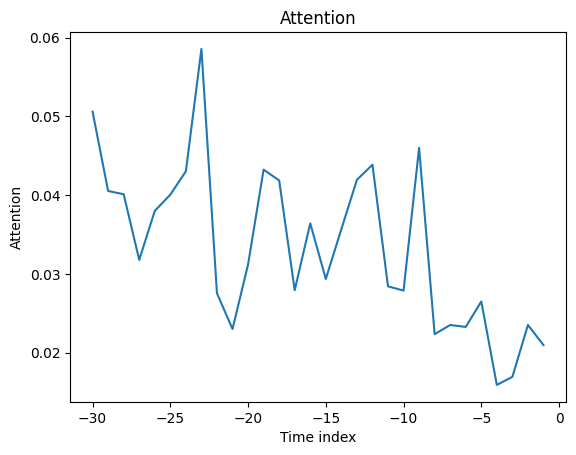

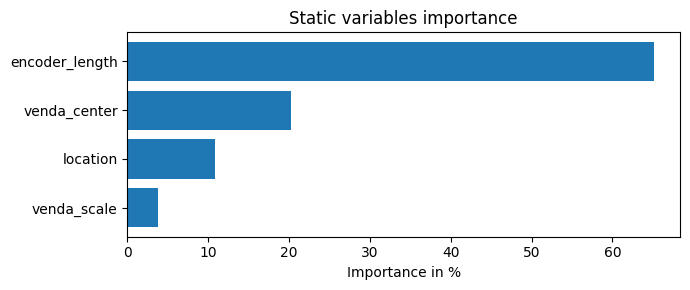

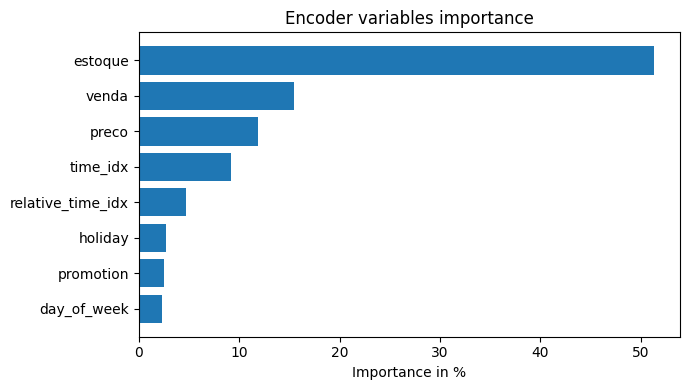

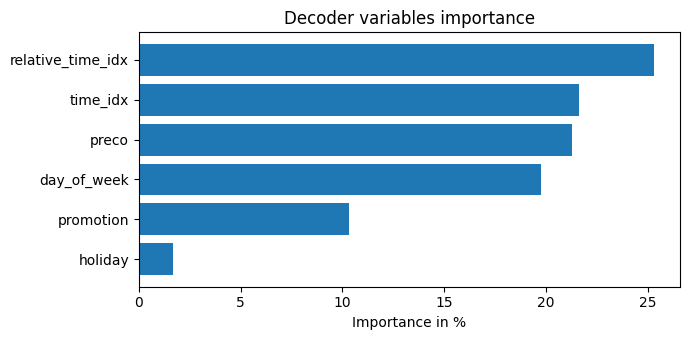

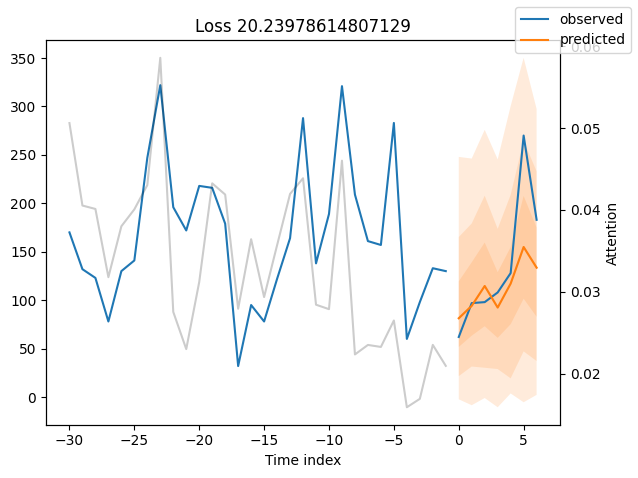

In [199]:
# Training
trainer.fit(
    tft,
    train_dataloaders=training.to_dataloader(train=True, batch_size=32),
    val_dataloaders=validation.to_dataloader(train=False, batch_size=32),
)

# 6. Requirement: Analyze Variable Importance
raw_preds = tft.predict(validation, mode="raw", return_x=True)
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")

# This will show which features (Promo, Holiday, Price) were most useful
figs = tft.plot_interpretation(interpretation)
plt.show()

# 7. Requirement: Generate Probabilistic Forecasts
# Plotting the first prediction with quantiles
tft.plot_prediction(raw_preds.x, raw_preds.output, idx=0, add_loss_to_title=True)
plt.show()

# 4.4

In [200]:
df = pd.read_csv('mock_kaggle.csv')
df["data"] = pd.to_datetime(df["data"])
df = df.sort_values("data")

# Required features
df["time_idx"] = np.arange(len(df))

# STORE ID AND LOCATION
store_ids = [str(i) for i in range(1, 2)]
top_1_state = ["Texas"]

np.random.seed(69)
store_locations = {store: np.random.choice(top_1_state) for store in store_ids}
df["store"] = np.random.choice(list(store_locations.keys()), size=len(df))
df["location"] = df["store"].map(store_locations)

# Time-varying features (Promotions & Holidays)
df["promotion"] = (df["preco"] < df["preco"].mean()).astype(str)
df["holiday"]   = df["data"].dt.dayofweek.map({5: "1", 6: "1"}).fillna("0")
df["day_of_week"] = df["data"].dt.dayofweek.astype(str)

# Train/Test Split (80/20)
split = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()
y_test = test_df['venda'].values

In [201]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Models
from statsmodels.tsa.arima.model import ARIMA
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from prophet import Prophet
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger

warnings.filterwarnings("ignore")

# Evaluation Metrics function
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

results_table = []
predictions_dict = {}

print("\n[1/4] Running ARIMA...")
start_time = time.time()
prices = train_df.set_index('data')['venda']

# Basic ARIMA doesn't use the holiday feature
model_arima = ARIMA(prices, order=(1, 1, 1)).fit()
forecast_obj = model_arima.get_forecast(steps=len(test_df))
forecast_mean = forecast_obj.predicted_mean
arima_time = time.time() - start_time

results_table.append({"Model": "ARIMA", **calculate_metrics(y_test, forecast_mean.values), "Time (s)": arima_time})
predictions_dict["ARIMA"] = forecast_mean.values

print("\n[2/4] Running Prophet...")
start_time = time.time()

prophet_train = train_df[['data', 'venda']].rename(columns={'data': 'ds', 'venda': 'y'})
prophet_test = test_df[['data', 'venda']].rename(columns={'data': 'ds', 'venda': 'y'})

# Format Holidays specifically for Prophet from the new setup
holidays_prophet = df[df["holiday"] == "1"][['data']].copy()
holidays_prophet['holiday'] = 'Weekend_Holiday' # Give it a dummy name Prophet requires
holidays_prophet = holidays_prophet.rename(columns={'data': 'ds'})

model_prophet = Prophet(
    holidays=holidays_prophet, 
    yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
    changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, seasonality_mode='additive'
)
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=len(prophet_test), freq='D', include_history=False)
forecast = model_prophet.predict(future)

prophet_time = time.time() - start_time
results_table.append({"Model": "Prophet", **calculate_metrics(prophet_test['y'].values, forecast['yhat'].values), "Time (s)": prophet_time})
predictions_dict["Prophet"] = forecast['yhat'].values

print("\n[3/4] Running LSTM...")
start_time = time.time()

class MultivariateSeqDataset(Dataset):
    def __init__(self, data, seq_len, horizon):
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.horizon = horizon
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        y = self.data[i + self.seq_len : i + self.seq_len + self.horizon, 0] # target is idx 0
        return x, y

class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size=5, hidden=64, layers=2, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, horizon))
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

scaler = MinMaxScaler()
# LSTM requires strictly numerical features, so we cast holiday to float
df['holiday_num'] = df['holiday'].astype(float)
features_to_scale = ['venda', 'estoque', 'preco', 'time_idx', 'holiday_num']

scaled_features = scaler.fit_transform(df[features_to_scale])
train_scaled = scaled_features[:split]

SEQ_LEN = 30
HORIZON = len(test_df)

dataset = MultivariateSeqDataset(train_scaled, seq_len=SEQ_LEN, horizon=HORIZON)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

model_lstm = LSTMSeq2Seq(input_size=5, hidden=64, layers=2, horizon=HORIZON)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)

# Training Loop
model_lstm.train()
for epoch in range(10): 
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()
        loss = nn.MSELoss()(model_lstm(x_batch), y_batch)
        loss.backward()
        optimizer.step()

# Forecasting
model_lstm.eval()
last_window = torch.FloatTensor(train_scaled[-SEQ_LEN:]).unsqueeze(0)
with torch.no_grad():
    lstm_pred_scaled = model_lstm(last_window).numpy().flatten()

dummy = np.zeros((len(lstm_pred_scaled), 5))
dummy[:, 0] = lstm_pred_scaled
lstm_pred = scaler.inverse_transform(dummy)[:, 0]

lstm_time = time.time() - start_time
results_table.append({"Model": "LSTM", **calculate_metrics(y_test, lstm_pred), "Time (s)": lstm_time})
predictions_dict["LSTM"] = lstm_pred

print("\n[4/4] Running TFT...")
start_time = time.time()
MAX_ENC = 30
MAX_PRED = len(test_df) 
training_cutoff = train_df["time_idx"].max()

training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx", target="venda", 
    group_ids=["store"], # Corrected to the newly defined "store" group
    max_encoder_length=MAX_ENC, max_prediction_length=MAX_PRED,
    static_categoricals=["location"], # Corrected to the newly defined "location" 
    time_varying_known_categoricals=["day_of_week", "promotion", "holiday"],
    time_varying_known_reals=["preco", "time_idx"],
    time_varying_unknown_reals=["venda", "estoque"],
    target_normalizer=GroupNormalizer(groups=["store"]),
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

tft = TemporalFusionTransformer.from_dataset(
    training, learning_rate=0.03, hidden_size=16, attention_head_size=2,
    dropout=0.1, hidden_continuous_size=8, loss=QuantileLoss()
)

trainer = pl.Trainer(
    max_epochs=10, accelerator="cpu", enable_model_summary=False,
    logger=CSVLogger(save_dir=".", name="tft_logs"), default_root_dir=".", log_every_n_steps=5
)

trainer.fit(
    tft, train_dataloaders=training.to_dataloader(train=True, batch_size=32),
    val_dataloaders=validation.to_dataloader(train=False, batch_size=32)
)

point_preds = tft.predict(validation, mode="prediction", return_x=False)
actuals = torch.cat([y[0] for x, y in iter(validation.to_dataloader(train=False, batch_size=32))])

tft_time = time.time() - start_time
results_table.append({"Model": "TFT", **calculate_metrics(actuals.numpy().flatten(), point_preds.numpy().flatten()), "Time (s)": tft_time})
predictions_dict["TFT"] = point_preds.numpy().flatten()

01:57:38 - cmdstanpy - INFO - Chain [1] start processing



[1/4] Running ARIMA...

[2/4] Running Prophet...


01:57:38 - cmdstanpy - INFO - Chain [1] done processing



[3/4] Running LSTM...


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



[4/4] Running TFT...


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


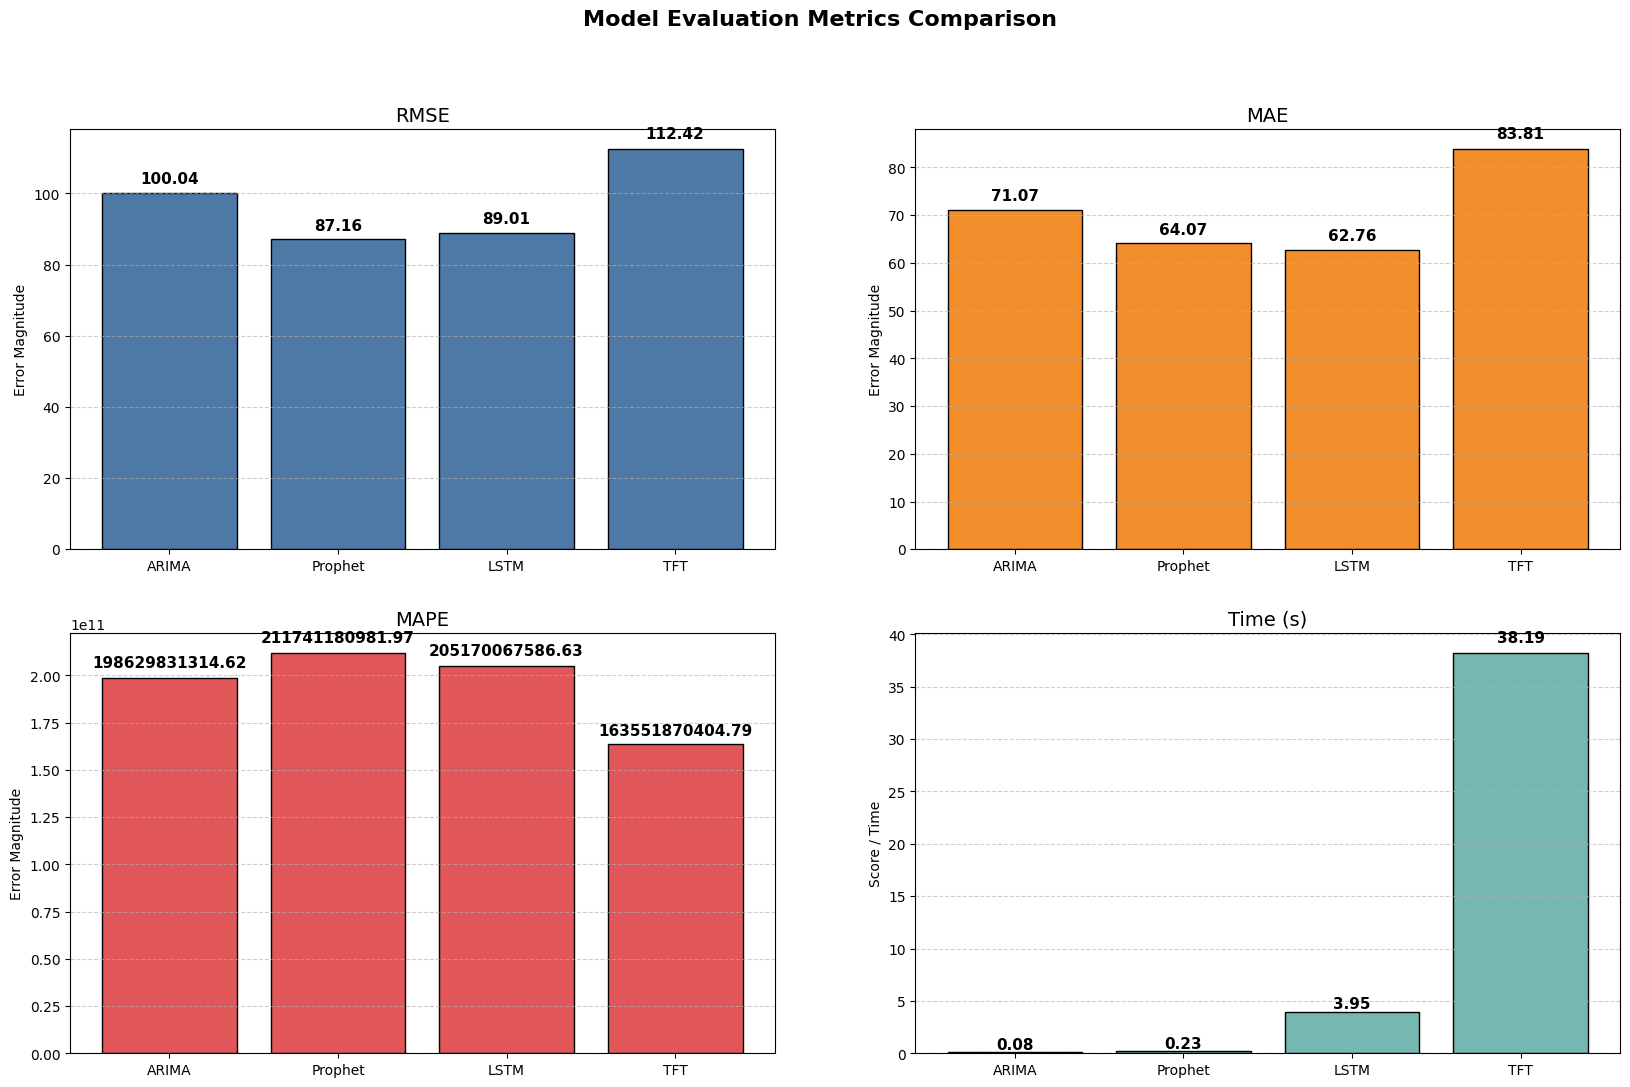

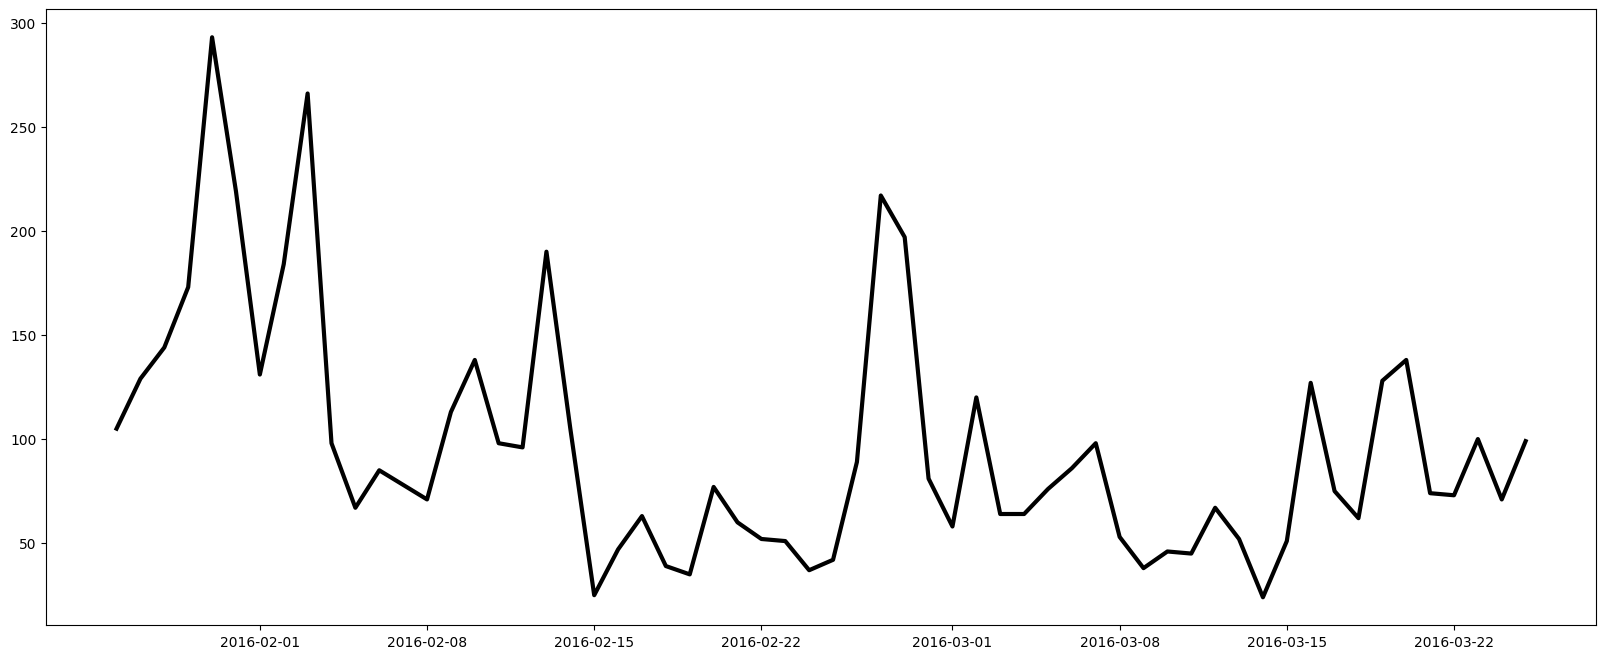

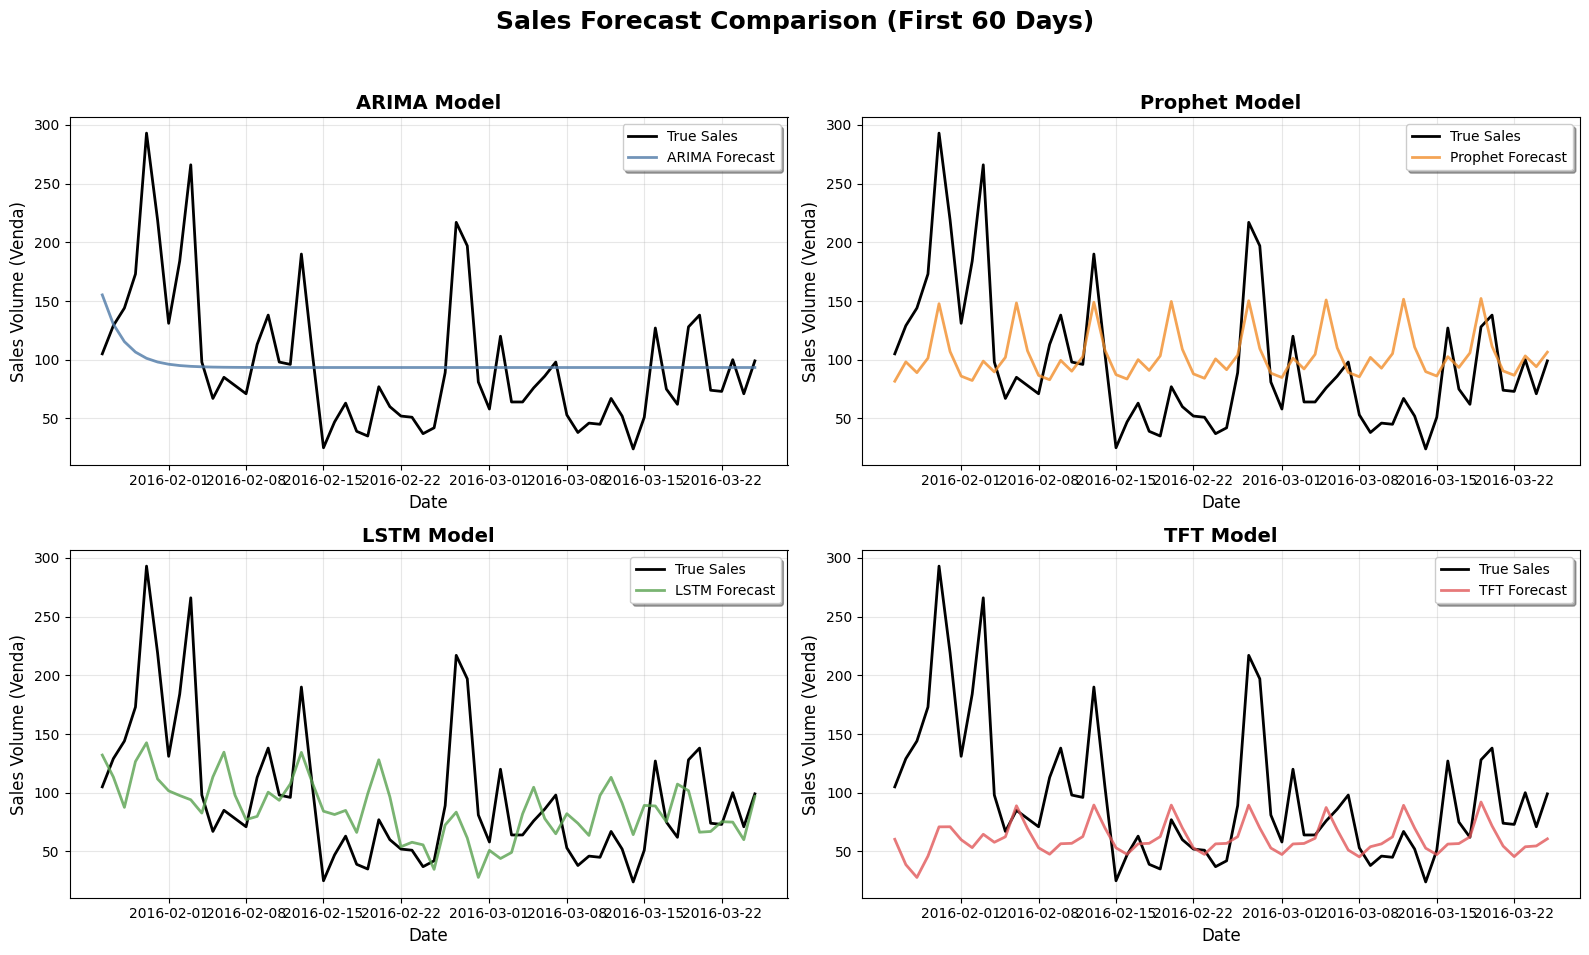

In [202]:
metrics_df = pd.DataFrame(results_table).set_index("Model")

# PLOT 1: Metrics Dashboard
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Model Evaluation Metrics Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'Time (s)']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    data = metrics_df[metric]
    
    # Create bars
    bars = ax.bar(data.index, data.values, color=colors[i], edgecolor='black')
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel('Score / Time' if metric == 'Time (s)' else 'Error Magnitude')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotate bars with exact numbers
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), 
                f'{yval:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

# PLOT 2: Forecast Time Series Overlay
plt.figure(figsize=(20, 8))

# Limit to 60 days
plot_limit = 60
dates_subset = test_df['data'].iloc[:plot_limit]
actuals_subset = y_test[:plot_limit]

plt.plot(dates_subset, actuals_subset, label='True Sales', color='black', linewidth=3)

# Style dictionaries
colors_pred = {'ARIMA': '#4e79a7', 'Prophet': '#f28e2b', 'LSTM': '#59a14f', 'TFT': '#e15759'}

# Plot each model's prediction
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten() # Flatten to easily iterate over them

# Iterate over models and axes simultaneously
for idx, (model_name, preds) in enumerate(predictions_dict.items()):
    ax = axes[idx]
    
    # 1. Plot the True Sales as a baseline in every subplot
    ax.plot(dates_subset, actuals_subset, 
            label='True Sales', color='black', linewidth=2)
    
    # 2. Plot the specific model's forecast
    ax.plot(dates_subset, preds[:plot_limit], 
            label=f'{model_name} Forecast', 
            color=colors_pred.get(model_name, 'gray'),
            linewidth=2, alpha=0.8)

    # 3. Format each subplot
    ax.set_title(f'{model_name} Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Sales Volume (Venda)', fontsize=12)
    ax.legend(loc='upper right', fontsize=10, shadow=True)
    ax.grid(True, alpha=0.3)

# Add a main title for the whole figure
plt.suptitle('Sales Forecast Comparison (First 60 Days)', fontsize=18, fontweight='bold')

# Adjust layout so subplots don't overlap with the main title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()